In [1]:
import pymc as pm
from pymc.sampling.jax import sample_numpyro_nuts
import pytensor as pt
import matplotlib.pyplot as plt

/home/fausto/mambaforge/envs/pymc_latest/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Simple tests

In [4]:
with pm.Model() as model:
    a = pm.Normal('a', size=3)
    b, updates = pt.scan(
        pt.tensor.add,
        sequences=[a]
    )
    c = pm.Normal(
        'c',
        mu=b
    )

In [16]:
with model:
    trace = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, c]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [5]:
with model:
    trace_jax = sample_numpyro_nuts()

Compiling...


/home/fausto/mambaforge/envs/pymc_latest/lib/python3.11/site-packages/pymc/sampling/jax.py:641: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


Compilation time =  0:00:03.194816
Sampling...


sample: 100%|████████████████████████████████████████| 2000/2000 [00:37<00:00, 53.66it/s, 7 steps of size 4.12e-01. acc. prob=0.93]


Sampling time =  0:02:52.129000
Transforming variables...
Transformation time =  0:00:00.007379


In [6]:
trace_jax

Inference data with groups:
	> posterior
	> sample_stats

# Actual model

In [2]:
import pandas as pd
import numpy as np

import pymc as pm
import arviz as az
import pytensor as theano
import pytensor.tensor as tt
tprint = theano.printing.Print
from pymc.sampling.jax import sample_numpyro_nuts

import itertools as it

In [10]:
###### Simulate experiment functions

def normalize(arr, axis=0):
    return arr / arr.sum(axis, keepdims=True)


def define_objects(n_beings=4, n_actions=3, full_output=False):
    
    being = range(n_beings)
    actions = range(n_beings, n_beings+n_actions)
    signals = range(n_beings+n_actions)

    scenes = np.array([
        i
        for i in it.product(being, actions, being)
        # Note: agent and patient can't be the same
        if i[0] != i[2]
    ])

    language_interpret = np.array(list(it.permutations(signals)))
    word_orders = np.array(list(it.permutations(range(3))))

    languages = []
    # for each interpretation function
    for inter in language_interpret:
        sub = []
        # for each word order
        for order in word_orders:
            subsub = []
            # for each scene
            # scene has: (agent, action, patient)
            for scene in scenes:
                # signals for [agent, action, patient]
                subsub.append(inter[scene][order])
            sub.append(subsub)
        languages.append(sub)
    languages = np.array(languages)
    
    if full_output:
        return scenes, languages, language_interpret, np.array(word_orders)
    return scenes, languages


def generate_trials(lang, n, scenes, n_scenes_trial):
    index_scenes = np.array([
        np.random.choice(
            len(scenes), 
            4,
            replace=False
        )
        for _ in range(n)
    ])
    
    true_scenes_index = np.random.choice(
        np.arange(n_scenes_trial), 
        size=len(index_scenes)
    )
    true_scenes = index_scenes[
        np.arange(len(index_scenes)),
        true_scenes_index
    ]
    utterances = lang[true_scenes]
    
    return true_scenes, index_scenes, utterances

def simulate_full_experiment(n_trials, n_participants):

    scenes, languages, language_interpret, word_orders = define_objects(
        full_output=True
    )

    true_scenes = []
    indices_scenes_trials = []
    signals = []

    ### Train each participant on different lang
    indices_true_language = [
        (
            np.random.randint(low=0, high=len(languages)), 
            np.random.randint(low=0, high=6)
        ) 
        for _ in range(n_participants)
    ]

    for i in range(n_participants):

        index_true_language = indices_true_language[i]

        trials = generate_trials(
            languages[index_true_language], 
            n=n_trials, 
            scenes=scenes, 
            n_scenes_trial=4
        )

        t_scenes, i_scenes_trials, sign = trials

        true_scenes.append(t_scenes)
        indices_scenes_trials.append(i_scenes_trials)
        signals.append(sign)

    true_scenes = np.swapaxes(true_scenes, 0, 1)
    indices_scenes_trials = np.swapaxes(indices_scenes_trials, 0, 1)
    signals = np.swapaxes(signals, 0, 1)

    scenes_trials = scenes[indices_scenes_trials]
    true_scenes_trials = scenes[true_scenes]
    
    returndict = {
        'true_scenes': true_scenes, 
        'indices_scenes_trials': indices_scenes_trials, 
        'signals': signals, 
        'scenes_trials': scenes_trials, 
        'true_scenes_trials': true_scenes_trials,
        'indices_true_language': np.array(indices_true_language)
    }
    
    return returndict


####### Define likelihood

def theano_normalize(tensor, axis):
    return tensor / tensor.sum(axis, keepdims=True)


def update_weights_theano_multiple_participants(scene, signal, 
                                                interpretation_weights_original, 
                                                word_order_weights_original, 
                                                word_orders, learning_weights):

    n_parti = interpretation_weights_original.shape[0]
    
    ### Snippet A (update interpretation weights)

    # get one-hot vectors for the indices as described in the notebook
    # in which to add the calculated weights that should be added.
    # Dimensions (participant, object in scene, word order, signal)
    # shape: (# participants, 3, 6, 3)
    mask_orders = tt.eq(
        tt.tile(word_orders, (n_parti,3,1,1)), 
        np.array([0,1,2])[None,:,None,None]
    )
    
    # Get the values from word_order_weights_original
    # to add to the various elements
    # using the one-hot vectors in mask_orders.
    # values_to_add: shape (# participants, 3, 3)
    # dims (participant, scene components, words in signal)
    # rows: (subj, obj, act)
    # cols: (first word, second word, third word)    
    values_to_add = (
        # get the weights compatible with each word order
        (word_order_weights_original[:,None,:,None] * mask_orders)
        # sum over word order dimension
        # to get the probability that it's ANY of those orders
        .sum(2)
    )
    
    # indicates which participant
    arg1 = tt.tile(tt.arange(n_parti).dimshuffle(0,'x','x'), (1,3,3))
    # indicates which signals (rows)
    arg2 = tt.tile(signal.dimshuffle(0,'x',1), (1,3,1))
    # indicates which meanings (columns)
    arg3 = tt.tile(scene.dimshuffle(0, 1,'x'), 3)
    
    # insert value to right locations
    # keep 0 everywhere else
    interpretation_to_add = tt.set_subtensor(
        # create an array with shape (participant, signal, meaning)
        tt.zeros(interpretation_weights_original.shape)[
            arg1, arg2, arg3
        ],
        values_to_add
    )
    
    # Create array with new weights and then normalize
    # in the meaning dimension 
    # (get a distribution over meanings given a signal
    # which makes sense since this is an interpretation matrix)
    # shape: participant, signal, meaning
    interpretation_weights = theano_normalize(
        # add to the original array
        interpretation_weights_original 
        + learning_weights[:,None,None]*interpretation_to_add,
        axis=-1
    )
    
    # Snippet B (update word order weights)
    
    # weights to add to the word order
    word_order_to_add = interpretation_weights_original[
        tt.tile(
            tt.arange(n_parti).dimshuffle(0,'x','x'), 
            (1,6,3)
        ),
        # for each participant, 
        # repeat signal once for each word order.
        # dims (participant, word order, signal)
        tt.tile(
            signal.dimshuffle(0,'x',1), 
            (1,6,1)
        ), 
        scene[:,word_orders]
    ].prod(-1)
        
    word_order_weights = theano_normalize(
        word_order_weights_original 
        + learning_weights[:,None]*word_order_to_add,
        1
    )
    
    return interpretation_weights, word_order_weights


def softmax_theano(x, axis):
    e_x = tt.exp(x - x.max(axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)


def probs_languages_to_probs_scenes_multiple_participants(
                    interpretation_weights, word_order_weights, 
                    signals, scenes_trials, word_orders, softmax_alphas):
    
    # meaning that each word would be expressing
    # assuming each word order is true
    # dims (trial, participant, scene in trial, word orders, 3), values: meanings
    # e.g., (40, 5, 4, 6, 3)
    meanings_trials_orders = scenes_trials[:,:,:,word_orders]
    
    # get the probability that the whole sentence 
    # observed in each trial expresses 
    # each of the scenes in the trial
    # assuming each word order in turn
    # Dimensions: 
    # (trial, participant, scene in trial, word order)
    prob_sentence_by_trial_given_order = (
        interpretation_weights[
            tt.arange(interpretation_weights.shape[0])[:,None,None,None,None],
            tt.arange(interpretation_weights.shape[1])[None,:,None,None,None],
            signals[:,:,None,None,:],
            meanings_trials_orders
        ]
        # get joint probability of the observed words
        # (for each trial, word order and scene)
        .prod(-1) 
    )
    
    # Marginalize out word order
    # to get probs of observed words in scene
    # Dimensions: (trial, participant, scene in trial)
    unnormalized_probs = (
        prob_sentence_by_trial_given_order
        # multiply by probability of word orders
        * word_order_weights.dimshuffle(0, 1, 'x', 2)
    ).sum(-1)
    
    if softmax_alphas is None:
        prodprobs = normalize(
            unnormalized_probs,
            2
        )
        
    else:
        prodprobs = softmax_theano(
            unnormalized_probs*softmax_alphas[:,None],
            -1
        )
        
    return prodprobs


def factory_weight_model_multiple_participants(true_scenes_trials, signals, word_orders,
                                               history_choices_indices, scenes_trials,
                                               scan_mode=None):
        
    # with all these dimensions I've decided to be careful 
    # and explicitly write down all the shapes
    n_trials, n_participants, n_scenes, _ = scenes_trials.shape
    coords = {
        "trial": np.arange(n_trials),
        "participant": np.arange(n_participants),
        "scene": np.arange(n_scenes),
        "component": ['agent', 'action', 'scene'],
        "word_order": np.arange(6),
        "sentence_position": np.arange(3)
    }
    
    with pm.Model(coords=coords) as model:

        ##### Create data
                
        true_scenes_trials_data = pm.Data(
            'true_scenes_trials',
            true_scenes_trials,
            dims=('trial', 'participant', 'component'),
            mutable=True
        )

        signals_data = pm.Data(
            'signals',
            signals,
            dims=('trial', 'participant', 'sentence_position'),
            mutable=True
        )

        word_orders_data = pm.Data(
            'word_orders',
            word_orders,
            dims=('word_order', 'sentence_position'),
            mutable=True
        )

        scenes_trials_data = pm.Data(
            'scenes_trials',
            scenes_trials,
            dims=('trial', 'participant', 'scene', 'component'),
            mutable=True
        )
        
        if history_choices_indices is None:
            history_choices_indices_data = None
        else:
            history_choices_indices_data = pm.Data(
                'history_choices_indices',
                history_choices_indices,
                dims=('trial', 'participant')
            )

        ####### Define priors
                                
        # sample population-level hyperprior
        # over the individual parameters of the Dirichlet following this: 
        # http://tdunning.blogspot.com/2010/04/sampling-dirichlet-distribution-revised.html
        gammas = pm.Gamma(
            'hyper_gammas',
            alpha=5,
            beta=2,
            dims=('word_order')
        )

        hyper_alpha = pm.Deterministic(
            'hyper_alpha',
            gammas.sum()
        )

        # shape (# participants, 6)
        # dim (participant, word order)
        word_order_weights = pm.Dirichlet(
            'word_order_prior', 
            gammas,
            dims=('participant', 'word_order')
        )

        # shape (# participants)
        learning_weights = pm.Gamma(
            'learning_weights',
            alpha=8.,
            beta=15.,
            dims=('participant')
        )
            
        softmax_alphas = pm.Exponential(
            'softmax_alpha',
            lam=0.5,
            dims=('participant')
        )

        ####### likelihood part
        
        # The participants' marginal prior over 
        # interpretation weights is fixed in advance
        # to be uniform, rather than estimated.
        # dims (participant, word, meaning)
        interpretation_weights = theano_normalize(
            tt.ones((n_participants,7,7)),
            axis=1
        )

        # scan is theano's way to do looping.
        # probs of each word-meaning connection
        # and each word order respectively
        (probs_interpretations, probs_word_orders), outputs_info = theano.scan(
            update_weights_theano_multiple_participants,
            sequences=[
                true_scenes_trials_data,
                signals_data
            ],
            outputs_info=[
                interpretation_weights,
                word_order_weights
            ],
            non_sequences=[
                word_orders_data,
                learning_weights
            ],
            mode=scan_mode
        )

        # dims (trial, participant, scenes in trial)
        # where there are always 4 scenes in the trial
        prob_scenes = probs_languages_to_probs_scenes_multiple_participants(
            probs_interpretations, 
            probs_word_orders, 
            signals_data, 
            scenes_trials_data, 
            word_orders_data,
            softmax_alphas
        )
        
        pm.Deterministic(
            'probs_scenes',
            prob_scenes
        )
                
        pm.Categorical(
            'chosen_scenes',
            p=prob_scenes,
            observed=history_choices_indices_data,
            dims=('trial', 'participant')
        )
        
    return model


def prior_predictive_sample(n_trials, n_participants):

    simulated_results = simulate_full_experiment(
        n_trials, 
        n_participants
    )

    scenes, languages, language_interpret, word_orders = define_objects(
        full_output=True
    )

    model = factory_weight_model_multiple_participants(
        true_scenes_trials=simulated_results['true_scenes_trials'], 
        signals=simulated_results['signals'], 
        scenes_trials=simulated_results['scenes_trials'],
        word_orders=word_orders,
        history_choices_indices=None
    )

    with model:
        simulated_data = pm.sample_prior_predictive(samples=1)

    return simulated_results, simulated_data

In [4]:
# get some samples to run inference with
simulated_results, data = prior_predictive_sample(
    n_trials=100, 
    n_participants=200
)

Sampling: [chosen_scenes, hyper_gammas, learning_weights, softmax_alpha, word_order_prior]


In [14]:
analysis_arrays = data.constant_data
observed = data.prior.chosen_scenes.values[0,0]

_,_,_, word_orders = define_objects(
    full_output=True
)

model = factory_weight_model_multiple_participants(
    true_scenes_trials=analysis_arrays['true_scenes_trials'],
    signals=analysis_arrays['signals'],
    word_orders=word_orders,
    history_choices_indices=observed,
    scenes_trials=analysis_arrays['scenes_trials'],
    scan_mode='JAX'
)

/home/fausto/mambaforge/envs/pymc_latest/lib/python3.11/site-packages/pymc/data.py:433: UserWarning: The `mutable` kwarg was not specified. Before v4.1.0 it defaulted to `pm.Data(mutable=True)`, which is equivalent to using `pm.MutableData()`. In v4.1.0 the default changed to `pm.Data(mutable=False)`, equivalent to `pm.ConstantData`. Use `pm.ConstantData`/`pm.MutableData` or pass `pm.Data(..., mutable=False/True)` to avoid this warning.
  warnings.warn(


# Make sure just `.sample()` works

In [9]:
with model:
    trace = pm.sample()

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [hyper_gammas]
>CompoundStep
>>Metropolis: [word_order_prior]
>>Metropolis: [learning_weights]
>>Metropolis: [softmax_alpha]


ValueError: Not enough samples to build a trace.

# Try with numpyro (does not work)

In [15]:
with model:
    trace = sample_numpyro_nuts(chains=1)

Compiling...


TypeError: Shapes must be 1D sequences of concrete values of integer type, got (200, 3, 1, 1, 1, 1, Traced<ShapedArray(int64[])>with<DynamicJaxprTrace(level=1/0)>, Traced<ShapedArray(int64[])>with<DynamicJaxprTrace(level=1/0)>).
If using `jit`, try using `static_argnums` or applying `jit` to smaller subfunctions.
The error occurred while tracing the function jax_funcified_fgraph at /tmp/tmp1yc2itg5:1 for jit. This concrete value was not available in Python because it depends on the value of the argument nominal_tensor_variable_2.
The error occurred while tracing the function jax_funcified_fgraph at /tmp/tmp1yc2itg5:1 for jit. This concrete value was not available in Python because it depends on the value of the argument nominal_tensor_variable_3.
Apply node that caused the error: True_div(Add.0, ExpandDims{axis=2}.0)
Toposort index: 25
Inputs types: [TensorType(float64, shape=(200, 7, 7)), TensorType(float64, shape=(200, 7, 1))]
Inputs shapes: [(200, 3, 1), (200, 1, 3), (200, 3), (200,

# Try using nutpie (does not work)

In [12]:
import nutpie

In [16]:
compiled_model = nutpie.compile_pymc_model(model)

AttributeError: module 'pymc.model' has no attribute 'make_initial_point_fn'

In [9]:
trace_pymc = nutpie.sample(
    compiled_model, 
    chains=10
)

ValueError: Logp function returned error Initialization of first point failed

# Use MHMC

In [53]:
with model:
    trace = pm.sample(
        draws=1000,
        chains=4,
        step=pm.Metropolis()
    )

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [hyper_gammas]
>Metropolis: [word_order_prior]
>Metropolis: [learning_weights]
>Metropolis: [softmax_alpha]


ValueError: Not enough samples to build a trace.

Process ForkPoolWorker-47:
Process ForkPoolWorker-45:
Process ForkPoolWorker-46:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/fausto/mambaforge/envs/pymc_latest/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/fausto/mambaforge/envs/pymc_latest/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/fausto/mambaforge/envs/pymc_latest/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/fausto/mambaforge/envs/pymc_latest/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/fausto/mambaforge/envs/pymc_latest/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/fausto/mambaforge/envs/pymc_latest/lib/python3.11/multiprocessing/process.py", line 108, in 

In [32]:
true_gammas = data.prior.hyper_gammas.values.squeeze()

In [34]:
true_gammas

array([2.26740532, 2.02859649, 1.99496548, 1.27671916, 2.58248947,
       2.40690737])

In [40]:
import seaborn as sns

<Axes: ylabel='Density'>

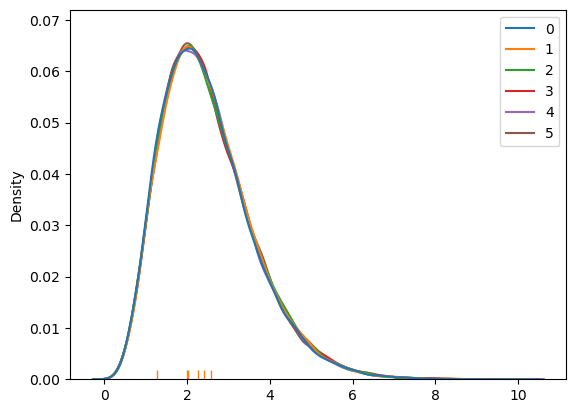

In [45]:
sns.kdeplot(
    trace.posterior.hyper_gammas.values.reshape(-1,6)
)

sns.rugplot(true_gammas)

# For discourse

In [10]:
import numpy as np
import pandas as pd

import pymc as pm
import arviz as az
import pytensor as theano
import pytensor.tensor as tt
tprint = theano.printing.Print

import itertools as it

###### Simulate experiment functions

def normalize(arr, axis=0):
    return arr / arr.sum(axis, keepdims=True)


def define_objects(n_beings=4, n_actions=3, full_output=False):
    
    being = range(n_beings)
    actions = range(n_beings, n_beings+n_actions)
    signals = range(n_beings+n_actions)

    scenes = np.array([
        i
        for i in it.product(being, actions, being)
        # Note: agent and patient can't be the same
        if i[0] != i[2]
    ])

    language_interpret = np.array(list(it.permutations(signals)))
    word_orders = np.array(list(it.permutations(range(3))))

    languages = []
    # for each interpretation function
    for inter in language_interpret:
        sub = []
        # for each word order
        for order in word_orders:
            subsub = []
            # for each scene
            # scene has: (agent, action, patient)
            for scene in scenes:
                # signals for [agent, action, patient]
                subsub.append(inter[scene][order])
            sub.append(subsub)
        languages.append(sub)
    languages = np.array(languages)
    
    if full_output:
        return scenes, languages, language_interpret, np.array(word_orders)
    return scenes, languages


def generate_trials(lang, n, scenes, n_scenes_trial):
    index_scenes = np.array([
        np.random.choice(
            len(scenes), 
            4,
            replace=False
        )
        for _ in range(n)
    ])
    
    true_scenes_index = np.random.choice(
        np.arange(n_scenes_trial), 
        size=len(index_scenes)
    )
    true_scenes = index_scenes[
        np.arange(len(index_scenes)),
        true_scenes_index
    ]
    utterances = lang[true_scenes]
    
    return true_scenes, index_scenes, utterances

def simulate_full_experiment(n_trials, n_participants):

    scenes, languages, language_interpret, word_orders = define_objects(
        full_output=True
    )

    true_scenes = []
    indices_scenes_trials = []
    signals = []

    ### Train each participant on different lang
    indices_true_language = [
        (
            np.random.randint(low=0, high=len(languages)), 
            np.random.randint(low=0, high=6)
        ) 
        for _ in range(n_participants)
    ]

    for i in range(n_participants):

        index_true_language = indices_true_language[i]

        trials = generate_trials(
            languages[index_true_language], 
            n=n_trials, 
            scenes=scenes, 
            n_scenes_trial=4
        )

        t_scenes, i_scenes_trials, sign = trials

        true_scenes.append(t_scenes)
        indices_scenes_trials.append(i_scenes_trials)
        signals.append(sign)

    true_scenes = np.swapaxes(true_scenes, 0, 1)
    indices_scenes_trials = np.swapaxes(indices_scenes_trials, 0, 1)
    signals = np.swapaxes(signals, 0, 1)

    scenes_trials = scenes[indices_scenes_trials]
    true_scenes_trials = scenes[true_scenes]
    
    returndict = {
        'true_scenes': true_scenes, 
        'indices_scenes_trials': indices_scenes_trials, 
        'signals': signals, 
        'scenes_trials': scenes_trials, 
        'true_scenes_trials': true_scenes_trials,
        'indices_true_language': np.array(indices_true_language)
    }
    
    return returndict


####### Define likelihood

def theano_normalize(tensor, axis):
    return tensor / tensor.sum(axis, keepdims=True)


def update_weights_theano_multiple_participants(scene, signal, 
                                                interpretation_weights_original, 
                                                word_order_weights_original, 
                                                word_orders, learning_weights):
    """
    This function takes a description of a single trial index of the experiment
    as well as the participant's current posterior over 
    interpretations and word orders
    and returns the updated participants' posterior.
    
    NOTE: This function calculates everything for *all agents* for one trial
    So it might differ from functions above that are written for one participant.
    TODO: Is it possible to rewrite this to do all trials at once efficiently? 
          Maybe some clever cumulative operation?
    
    Parameters
    ----------
    scene: array
        dims (participant, 3)
        Description of scene that the signal describes.
        A single scene is described by (agent, action, patient)
    signal: array
        dims (participant, 3)
        The three columns report the indices of the signals
    interpretation_weights_original: array
        dims: (participant, signal, meaning)
        shape: (# participants, 7, 7)
        Each row is a the prob of the signal referring to each
        meaning. Gets updated in this function in light
        of evidence given by scene/signal combos.
    word_order_weights_original: array
        dims: (participant, word order)
        shape: (# participants, 6)
    word_orders: array
        dims: (word order,3)
        shape: (6,3)
        Word orders (see functions above for description)
    learning_weights: array
        dims: (participant)
        The learning weight of each participant
    Returns
    -------
    tuple of arrays
        interpretation_weights: array
            Same shape as interpretation_weights_original
            NOTE: normalized before returning
        word_order_weights: array
            Same shape as word_order_weights_original
            NOTE: normalized before returning
    """
    
    n_parti = interpretation_weights_original.shape[0]
    
    ### Snippet A (update interpretation weights)

    # get one-hot vectors for the indices as described in the notebook
    # in which to add the calculated weights that should be added.
    # Dimensions (participant, object in scene, word order, signal)
    # shape: (# participants, 3, 6, 3)
    mask_orders = tt.eq(
        tt.tile(word_orders, (n_parti,3,1,1)), 
        np.array([0,1,2])[None,:,None,None]
    )
    
    # Get the values from word_order_weights_original
    # to add to the various elements
    # using the one-hot vectors in mask_orders.
    # values_to_add: shape (# participants, 3, 3)
    # dims (participant, scene components, words in signal)
    # rows: (subj, obj, act)
    # cols: (first word, second word, third word)    
    values_to_add = (
        # get the weights compatible with each word order
        (word_order_weights_original[:,None,:,None] * mask_orders)
        # sum over word order dimension
        # to get the probability that it's ANY of those orders
        .sum(2)
    )
    
    # indicates which participant
    arg1 = tt.tile(tt.arange(n_parti).dimshuffle(0,'x','x'), (1,3,3))
    # indicates which signals (rows)
    arg2 = tt.tile(signal.dimshuffle(0,'x',1), (1,3,1))
    # indicates which meanings (columns)
    arg3 = tt.tile(scene.dimshuffle(0, 1,'x'), 3)
    
    # insert value to right locations
    # keep 0 everywhere else
    interpretation_to_add = tt.set_subtensor(
        # create an array with shape (participant, signal, meaning)
        tt.zeros(interpretation_weights_original.shape)[
            arg1, arg2, arg3
        ],
        values_to_add
    )
    
    # Create array with new weights and then normalize
    # in the meaning dimension 
    # (get a distribution over meanings given a signal
    # which makes sense since this is an interpretation matrix)
    # shape: participant, signal, meaning
    interpretation_weights = theano_normalize(
        # add to the original array
        interpretation_weights_original 
        + learning_weights[:,None,None]*interpretation_to_add,
        axis=-1
    )
    
    # Snippet B (update word order weights)
    
    # weights to add to the word order
    word_order_to_add = interpretation_weights_original[
        tt.tile(
            tt.arange(n_parti).dimshuffle(0,'x','x'), 
            (1,6,3)
        ),
        # for each participant, 
        # repeat signal once for each word order.
        # dims (participant, word order, signal)
        tt.tile(
            signal.dimshuffle(0,'x',1), 
            (1,6,1)
        ), 
        scene[:,word_orders]
    ].prod(-1)
        
    word_order_weights = theano_normalize(
        word_order_weights_original 
        + learning_weights[:,None]*word_order_to_add,
        1
    )
    
    return interpretation_weights, word_order_weights


def softmax_theano(x, axis):
    e_x = tt.exp(x - x.max(axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)


def probs_languages_to_probs_scenes_multiple_participants(
                    interpretation_weights, word_order_weights, 
                    signals, scenes_trials, word_orders, softmax_alphas):
    """
    Finds probability of choosing each of the four scenes in `scenes`
    given the observed utterance and the current probabilities 
    of word-meaning association and word orders
    
    Parameters
    ----------
    interpretation_weights: array
        Dimensions: (trial, participant, word, meaning)
        NOTE: Trial dimension was added in the scan
    word_order_weights: array
        Dimensions: (trial, participant, word order)
        NOTE: Trial dimension was added in the scan
    signals: array
        Dimensions: (trial, participant, sentence position)
    scenes_trials: array
        Dimensions: (trial, participant, scene, component)
    word_orders: array
        Dimensions: (word order, sentence position)
    """
    
    # meaning that each word would be expressing
    # assuming each word order is true
    # dims (trial, participant, scene in trial, word orders, 3), values: meanings
    # e.g., (40, 5, 4, 6, 3)
    meanings_trials_orders = scenes_trials[:,:,:,word_orders]
    
    # get the probability that the whole sentence 
    # observed in each trial expresses 
    # each of the scenes in the trial
    # assuming each word order in turn
    # Dimensions: 
    # (trial, participant, scene in trial, word order)
    prob_sentence_by_trial_given_order = (
        interpretation_weights[
            tt.arange(interpretation_weights.shape[0])[:,None,None,None,None],
            tt.arange(interpretation_weights.shape[1])[None,:,None,None,None],
            signals[:,:,None,None,:],
            meanings_trials_orders
        ]
        # get joint probability of the observed words
        # (for each trial, word order and scene)
        .prod(-1) 
    )
    
    # Marginalize out word order
    # to get probs of observed words in scene
    # Dimensions: (trial, participant, scene in trial)
    unnormalized_probs = (
        prob_sentence_by_trial_given_order
        # multiply by probability of word orders
        * word_order_weights.dimshuffle(0, 1, 'x', 2)
    ).sum(-1)
    
    if softmax_alphas is None:
        prodprobs = normalize(
            unnormalized_probs,
            2
        )
        
    else:
        prodprobs = softmax_theano(
            unnormalized_probs*softmax_alphas[:,None],
            -1
        )
        
    return prodprobs


def factory_weight_model_multiple_participants(true_scenes_trials, signals, word_orders,
                                               history_choices_indices, scenes_trials):
    """
    Parameters
    ----------
    history_choices_indices: None or array
        If none, the model is defined without observed
    """
        
    # with all these dimensions I've decided to be careful 
    # and explicitly write down all the shapes
    n_trials, n_participants, n_scenes, _ = scenes_trials.shape
    coords = {
        "trial": np.arange(n_trials),
        "participant": np.arange(n_participants),
        "scene": np.arange(n_scenes),
        "component": ['agent', 'action', 'scene'],
        "word_order": np.arange(6),
        "sentence_position": np.arange(3)
    }
    
    with pm.Model(coords=coords) as model:

        ##### Create data
                
        true_scenes_trials_data = pm.Data(
            'true_scenes_trials',
            true_scenes_trials,
            dims=('trial', 'participant', 'component'),
            mutable=True
        )

        signals_data = pm.Data(
            'signals',
            signals,
            dims=('trial', 'participant', 'sentence_position'),
            mutable=True
        )

        word_orders_data = pm.Data(
            'word_orders',
            word_orders,
            dims=('word_order', 'sentence_position'),
            mutable=True
        )

        scenes_trials_data = pm.Data(
            'scenes_trials',
            scenes_trials,
            dims=('trial', 'participant', 'scene', 'component'),
            mutable=True
        )
        
        if history_choices_indices is None:
            history_choices_indices_data = None
        else:
            history_choices_indices_data = pm.Data(
                'history_choices_indices',
                history_choices_indices,
                dims=('trial', 'participant')
            )

        ####### Define priors
                                
        # sample population-level hyperprior
        # over the individual parameters of the Dirichlet following this: 
        # http://tdunning.blogspot.com/2010/04/sampling-dirichlet-distribution-revised.html
        gammas = pm.Gamma(
            'hyper_gammas',
            alpha=5,
            beta=2,
            dims=('word_order')
        )

#         hyper_alpha = pm.Deterministic(
#             'hyper_alpha',
#             gammas.sum()
#         )

        # shape (# participants, 6)
        # dim (participant, word order)
        word_order_weights = pm.Dirichlet(
            'word_order_prior', 
            gammas,
            dims=('participant', 'word_order')
        )


        # shape (# participants)
        learning_weights = pm.Gamma(
            'learning_weights',
            alpha=8.,
            beta=15.,
            dims=('participant')
        )
            
        softmax_alphas = pm.Exponential(
            'softmax_alpha',
            lam=0.5,
            dims=('participant')
        )

        ####### likelihood part
        
        # The participants' marginal prior over 
        # interpretation weights is fixed in advance
        # to be uniform, rather than estimated.
        # dims (participant, word, meaning)
        interpretation_weights = theano_normalize(
            tt.ones((n_participants,7,7)),
            axis=1
        )

        # scan is theano's way to do looping.
        # probs of each word-meaning connection
        # and each word order respectively
        (probs_interpretations, probs_word_orders), outputs_info = theano.scan(
            update_weights_theano_multiple_participants,
            sequences=[
                true_scenes_trials_data,
                signals_data
            ],
            outputs_info=[
                interpretation_weights,
                word_order_weights
            ],
            non_sequences=[
                word_orders_data,
                learning_weights
            ]
        )

        # dims (trial, participant, scenes in trial)
        # where there are always 4 scenes in the trial
        prob_scenes = probs_languages_to_probs_scenes_multiple_participants(
            probs_interpretations, 
            probs_word_orders, 
            signals_data, 
            scenes_trials_data, 
            word_orders_data,
            softmax_alphas
        )
        
        pm.Categorical(
            'chosen_scenes',
            p=prob_scenes,
            observed=history_choices_indices_data,
            dims=('trial', 'participant')
        )
        
    return model


def prior_predictive_sample(n_trials, n_participants):

    simulated_results = simulate_full_experiment(
        n_trials, 
        n_participants
    )

    scenes, languages, language_interpret, word_orders = define_objects(
        full_output=True
    )

    model = factory_weight_model_multiple_participants(
        true_scenes_trials=simulated_results['true_scenes_trials'], 
        signals=simulated_results['signals'], 
        scenes_trials=simulated_results['scenes_trials'],
        word_orders=word_orders,
        history_choices_indices=None
    )

    with model:
        simulated_data = pm.sample_prior_predictive(samples=1)

    return simulated_results, simulated_data

In [11]:
# get some samples to run inference with
simulated_results, data = prior_predictive_sample(
    n_trials=10, 
    n_participants=10
)

analysis_arrays = data.constant_data
observed = data.prior.chosen_scenes.values[0,0]

_,_,_, word_orders = define_objects(
    full_output=True
)

model = factory_weight_model_multiple_participants(
    true_scenes_trials=analysis_arrays['true_scenes_trials'],
    signals=analysis_arrays['signals'],
    word_orders=word_orders,
    history_choices_indices=observed,
    scenes_trials=analysis_arrays['scenes_trials'],
)

Sampling: [chosen_scenes, hyper_gammas, learning_weights, softmax_alpha, word_order_prior]
/home/fausto/mambaforge/envs/pymc_latest/lib/python3.11/site-packages/pymc/data.py:433: UserWarning: The `mutable` kwarg was not specified. Before v4.1.0 it defaulted to `pm.Data(mutable=True)`, which is equivalent to using `pm.MutableData()`. In v4.1.0 the default changed to `pm.Data(mutable=False)`, equivalent to `pm.ConstantData`. Use `pm.ConstantData`/`pm.MutableData` or pass `pm.Data(..., mutable=False/True)` to avoid this warning.
  warnings.warn(


In [2]:
with model:
    trace = pm.sample()

Sampling: [chosen_scenes, hyper_gammas, learning_weights, softmax_alpha, word_order_prior]
/home/fausto/mambaforge/envs/pymc_latest/lib/python3.11/site-packages/pymc/data.py:433: UserWarning: The `mutable` kwarg was not specified. Before v4.1.0 it defaulted to `pm.Data(mutable=True)`, which is equivalent to using `pm.MutableData()`. In v4.1.0 the default changed to `pm.Data(mutable=False)`, equivalent to `pm.ConstantData`. Use `pm.ConstantData`/`pm.MutableData` or pass `pm.Data(..., mutable=False/True)` to avoid this warning.
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [hyper_gammas]
>CompoundStep
>>Metropolis: [word_order_prior]
>>Metropolis: [learning_weights]
>>Metropolis: [softmax_alpha]


ValueError: Not enough samples to build a trace.

In [6]:
model.cont_vars

/home/fausto/mambaforge/envs/pymc_latest/lib/python3.11/site-packages/pymc/model/core.py:904: FutureWarning: Model.cont_vars has been deprecated. Use Model.continuous_value_vars instead.
  warnings.warn(


[hyper_gammas_log__,
 word_order_prior_simplex__,
 learning_weights_log__,
 softmax_alpha_log__]

In [22]:
model.dlogp(vars=[model.hyper_gammas])

# chosen_scenes, hyper_gammas, learning_weights, softmax_alpha, word_order_prior

Reshape{1}.0